<a href="https://colab.research.google.com/github/Alexd17d/Sistemas-Informacion/blob/main/Taller_Auditor%C3%ADa_de_Desempe%C3%B1o_para_Negocios_Digitales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [57]:
import pandas as pd
import numpy as np
from IPython.display import display

# Generar datos simulados
np.random.seed(42) # Para mantener consistencia
data = {
    'ID_Transaccion': range(1001, 1051),
    'Canal': np.random.choice(['Web Desktop', 'App Móvil'], 50, p=[0.4, 0.6]),
    'Metodo_Pago': np.random.choice(['Tarjeta Crédito', 'PayPal', 'Transferencia'], 50),
    'Total_Venta': np.random.randint(20, 500, 50), # Ventas entre $20 y $500
    'Categoria': np.random.choice(['Electrónica', 'Moda', 'Hogar'], 50)
}
df = pd.DataFrame(data)


print("Visualización de los primeros registros del TPS:")
display(df.head())

print("\nRESULTADOS DE LOS 4 KPIs")

# KPI 1: Volumen de Participación Operativa
print("\n► KPI 1: Participación Operativa")
kpi_1 = df['Canal'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%'
display(kpi_1.to_frame(name='Porcentaje de Transacciones'))

# KPI 2: Ingresos Brutos Totales (Gross Revenue)
print("\n► KPI 2: Ingresos Brutos Totales por Canal")
kpi_2 = df.groupby('Canal')['Total_Venta'].sum().map('${:,.2f}'.format)
display(kpi_2.to_frame(name='Ingresos Totales'))

# KPI 3: Ticket Promedio por Canal (AOV)
print("\n► KPI 3: Ticket Promedio de Venta (AOV)")
kpi_3 = df.groupby('Canal')['Total_Venta'].mean().round(2).map('${:,.2f}'.format)
display(kpi_3.to_frame(name='Ticket Promedio'))

# KPI 4: Rendimiento por Categoría (Matriz Cruzada)
print("\n► KPI 4: Rendimiento Cruzado por Categoría y Canal")
kpi_4 = df.pivot_table(values='Total_Venta', index='Categoria', columns='Canal', aggfunc='mean').round(2)
for col in kpi_4.columns:
    kpi_4[col] = kpi_4[col].map('${:,.2f}'.format)
display(kpi_4)

Visualización de los primeros registros del TPS:


,ID_Transaccion,Canal,Metodo_Pago,Total_Venta,Categoria
0,1001,Web Desktop,Transferencia,235,Moda
1,1002,App Móvil,PayPal,312,Moda
2,1003,App Móvil,PayPal,118,Electrónica
3,1004,App Móvil,PayPal,191,Moda
4,1005,Web Desktop,PayPal,379,Electrónica



RESULTADOS DE LOS 4 KPIs

► KPI 1: Participación Operativa


,Porcentaje de Transacciones
Canal,
App Móvil,52.0%
Web Desktop,48.0%



► KPI 2: Ingresos Brutos Totales por Canal


,Ingresos Totales
Canal,
App Móvil,"$6,779.00"
Web Desktop,"$5,549.00"



► KPI 3: Ticket Promedio de Venta (AOV)


,Ticket Promedio
Canal,
App Móvil,$260.73
Web Desktop,$231.21



► KPI 4: Rendimiento Cruzado por Categoría y Canal


Canal,App Móvil,Web Desktop
Categoria,,
Electrónica,$292.90,$260.60
Hogar,$277.33,$145.43
Moda,$218.60,$275.00


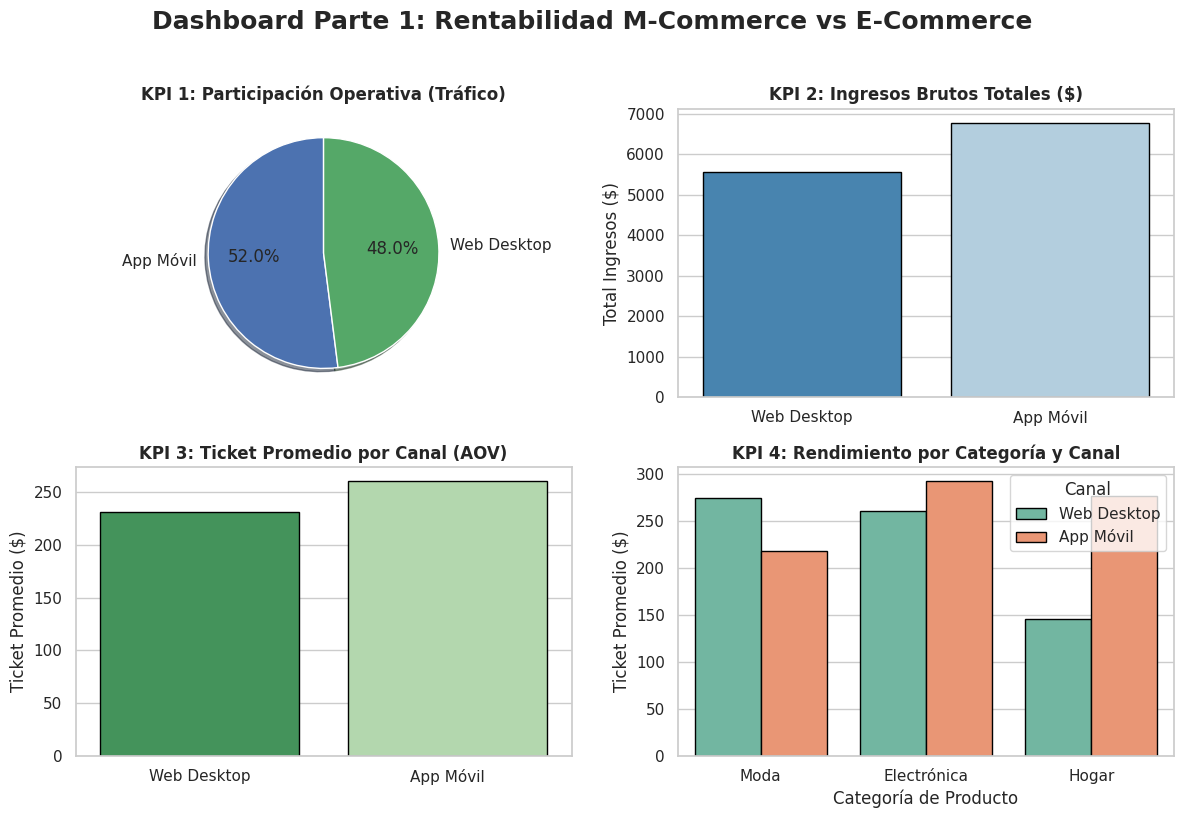

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Dashboard Parte 1: Rentabilidad M-Commerce vs E-Commerce', fontsize=18, fontweight='bold', y=1.02)

# KPI 1: Participación Operativa (Gráfico de Pastel)
canal_counts = df['Canal'].value_counts()
axes[0, 0].pie(canal_counts, labels=canal_counts.index, autopct='%1.1f%%',
               startangle=90, colors=['#4C72B0', '#55A868'], shadow=True, wedgeprops=dict(edgecolor='w'))
axes[0, 0].set_title('KPI 1: Participación Operativa (Tráfico)', fontweight='bold')

# KPI 2: Ingresos Brutos Totales (Gráfico de Barras)
sns.barplot(ax=axes[0, 1], data=df, x='Canal', y='Total_Venta', estimator=sum,
            errorbar=None, palette='Blues_r', edgecolor='black')
axes[0, 1].set_title('KPI 2: Ingresos Brutos Totales ($)', fontweight='bold')
axes[0, 1].set_ylabel('Total Ingresos ($)')
axes[0, 1].set_xlabel('')

# KPI 3: Ticket Promedio - AOV (Gráfico de Barras)
sns.barplot(ax=axes[1, 0], data=df, x='Canal', y='Total_Venta',
            errorbar=None, palette='Greens_r', edgecolor='black')
axes[1, 0].set_title('KPI 3: Ticket Promedio por Canal (AOV)', fontweight='bold')
axes[1, 0].set_ylabel('Ticket Promedio ($)')
axes[1, 0].set_xlabel('')

# KPI 4: Rendimiento Cruzado por Categoría (Barras Agrupadas)
sns.barplot(ax=axes[1, 1], data=df, x='Categoria', y='Total_Venta', hue='Canal',
            errorbar=None, palette='Set2', edgecolor='black')
axes[1, 1].set_title('KPI 4: Rendimiento por Categoría y Canal', fontweight='bold')
axes[1, 1].set_ylabel('Ticket Promedio ($)')
axes[1, 1].set_xlabel('Categoría de Producto')

plt.tight_layout()
plt.show()

In [40]:
import zipfile
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid") # Estilo estético para las gráficas

print("1. Extrayendo 'ecommerce.zip' y preparando datos reales...")
with zipfile.ZipFile('ecommerce.zip', 'r') as zip_ref:
    csv_filename = [name for name in zip_ref.namelist() if name.endswith('.csv')][0]
    zip_ref.extract(csv_filename)

# Cargar y Limpiar Datos
df_raw = pd.read_csv(csv_filename)
df_clean = df_raw.drop_duplicates().dropna()

# Quitar columna ID que no aporta a los KPIs
if 'ID' in df_clean.columns:
    df_clean = df_clean.drop(columns=['ID'])

print(f"Limpieza finalizada exitosamente.")
print(f"Registros listos para graficar: {df_clean.shape[0]}")
display(df_clean.head(3))

1. Extrayendo 'ecommerce.zip' y preparando datos reales...
Limpieza finalizada exitosamente.
Registros listos para graficar: 10999


,Warehouse_block,Mode_of_Shipment,Customer_care_calls,Customer_rating,Cost_of_the_Product,Prior_purchases,Product_importance,Gender,Discount_offered,Weight_in_gms,Reached.on.Time_Y.N
0,D,Flight,4,2,177,3,low,F,44,1233,1
1,F,Flight,4,5,216,2,low,M,59,3088,1
2,A,Flight,2,2,183,4,low,M,48,3374,1


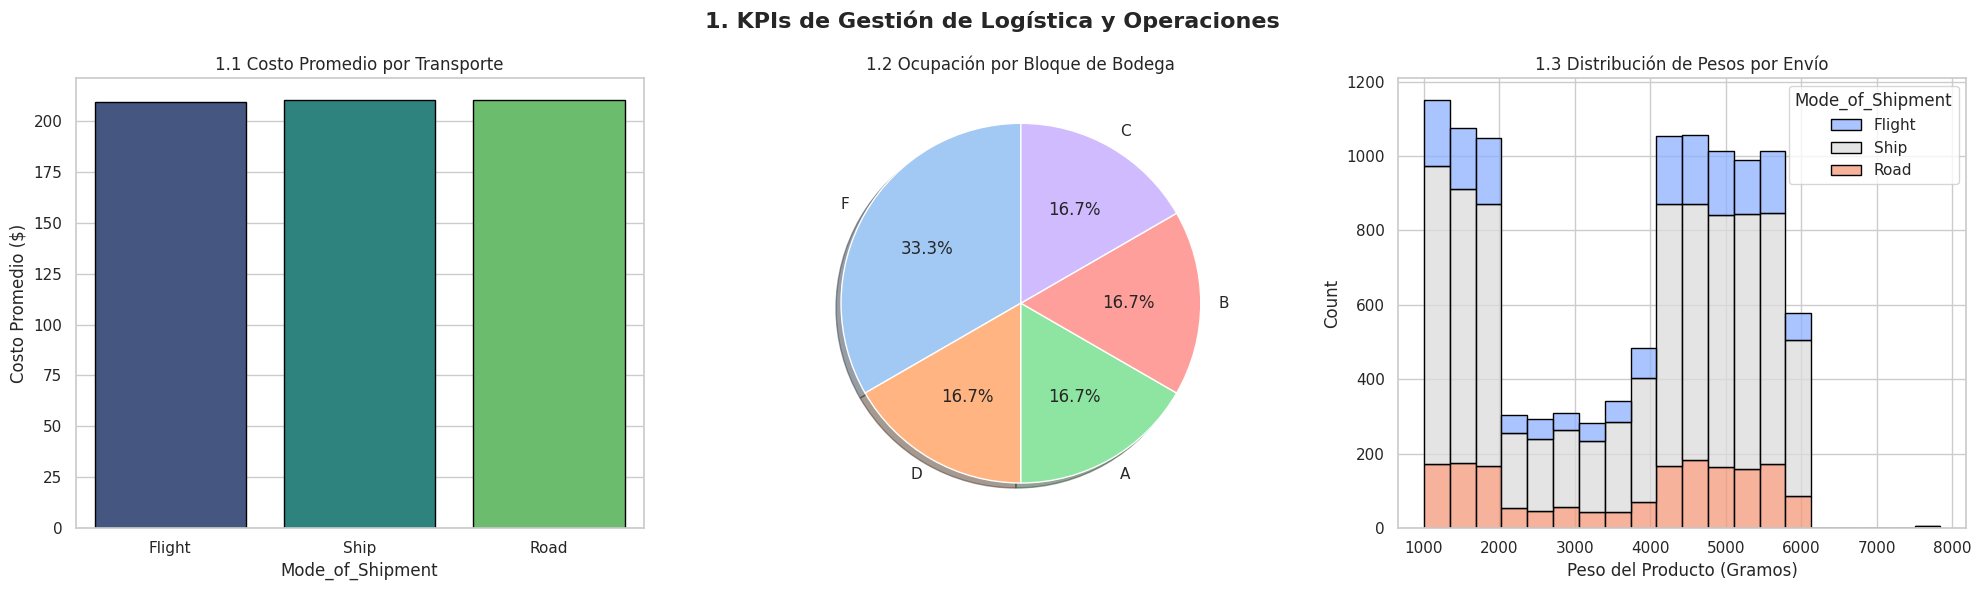

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('1. KPIs de Gestión de Logística y Operaciones', fontsize=16, fontweight='bold')

# KPI 1.1: Costo Promedio por Envío
sns.barplot(ax=axes[0], data=df_clean, x='Mode_of_Shipment', y='Cost_of_the_Product', errorbar=None, palette='viridis', edgecolor='black')
axes[0].set_title('1.1 Costo Promedio por Transporte')
axes[0].set_ylabel('Costo Promedio ($)')

# KPI 1.2: Ocupación por Bloque de Bodega
bodegas = df_clean['Warehouse_block'].value_counts()
axes[1].pie(bodegas.values, labels=bodegas.index, autopct='%1.1f%%', colors=sns.color_palette('pastel'), shadow=True, startangle=90)
axes[1].set_title('1.2 Ocupación por Bloque de Bodega')

# KPI 1.3: Peso Promedio por Modo de Envío
sns.histplot(ax=axes[2], data=df_clean, x='Weight_in_gms', hue='Mode_of_Shipment', multiple='stack', palette='coolwarm', bins=20, edgecolor='black')
axes[2].set_title('1.3 Distribución de Pesos por Envío')
axes[2].set_xlabel('Peso del Producto (Gramos)')

plt.tight_layout()
plt.show()

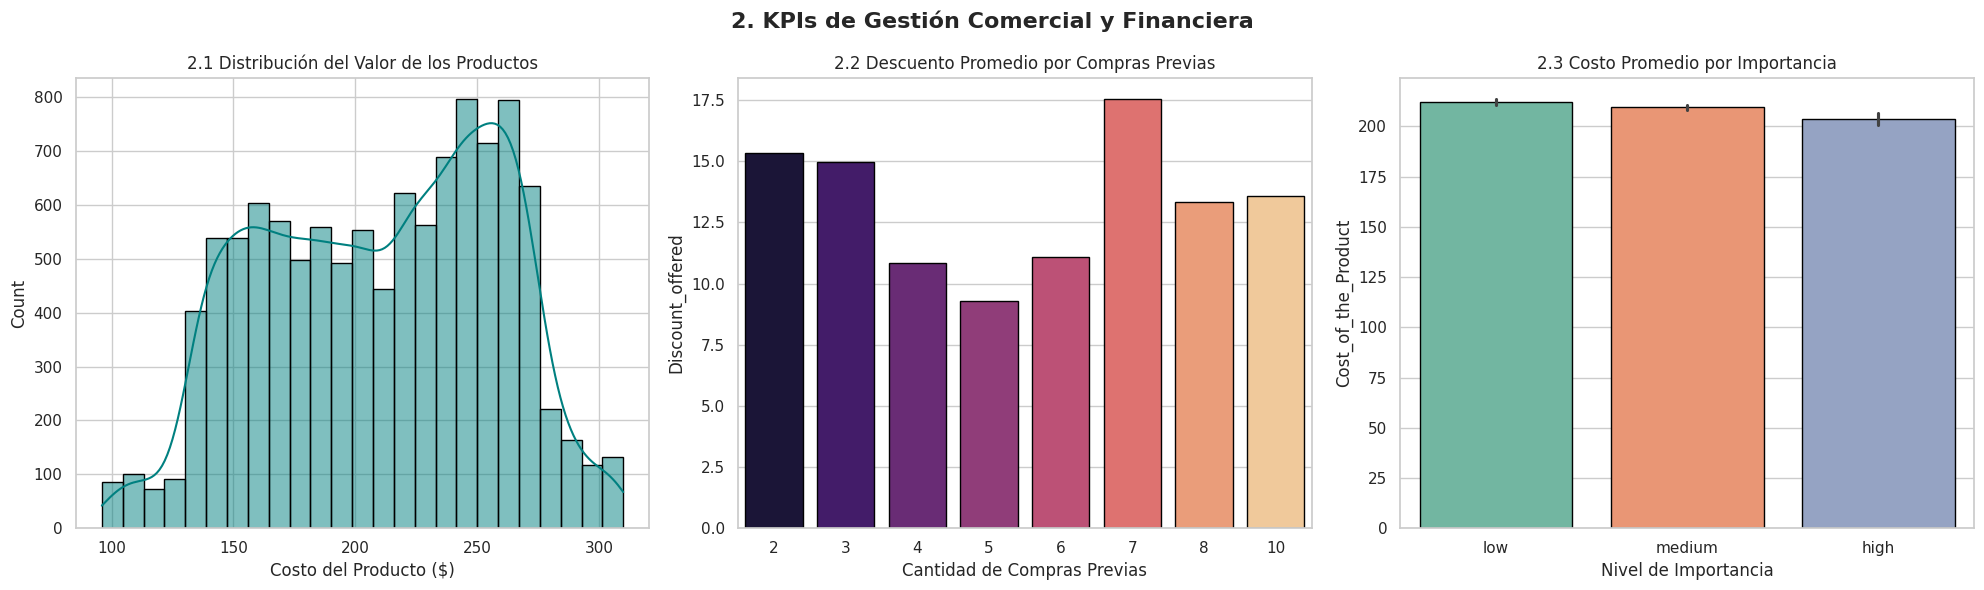

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('2. KPIs de Gestión Comercial y Financiera', fontsize=16, fontweight='bold')

# KPI 2.1: Ingreso y Costo Promedio
sns.histplot(ax=axes[0], data=df_clean, x='Cost_of_the_Product', kde=True, color='teal', bins=25, edgecolor='black')
axes[0].set_title('2.1 Distribución del Valor de los Productos')
axes[0].set_xlabel('Costo del Producto ($)')

# KPI 2.2: Descuento Promedio Otorgado
sns.barplot(ax=axes[1], data=df_clean, x='Prior_purchases', y='Discount_offered', errorbar=None, palette='magma', edgecolor='black')
axes[1].set_title('2.2 Descuento Promedio por Compras Previas')
axes[1].set_xlabel('Cantidad de Compras Previas')

# KPI 2.3: Margen por Importancia del Producto
sns.barplot(ax=axes[2], data=df_clean, x='Product_importance', y='Cost_of_the_Product', order=['low', 'medium', 'high'], palette='Set2', edgecolor='black')
axes[2].set_title('2.3 Costo Promedio por Importancia')
axes[2].set_xlabel('Nivel de Importancia')

plt.tight_layout()
plt.show()

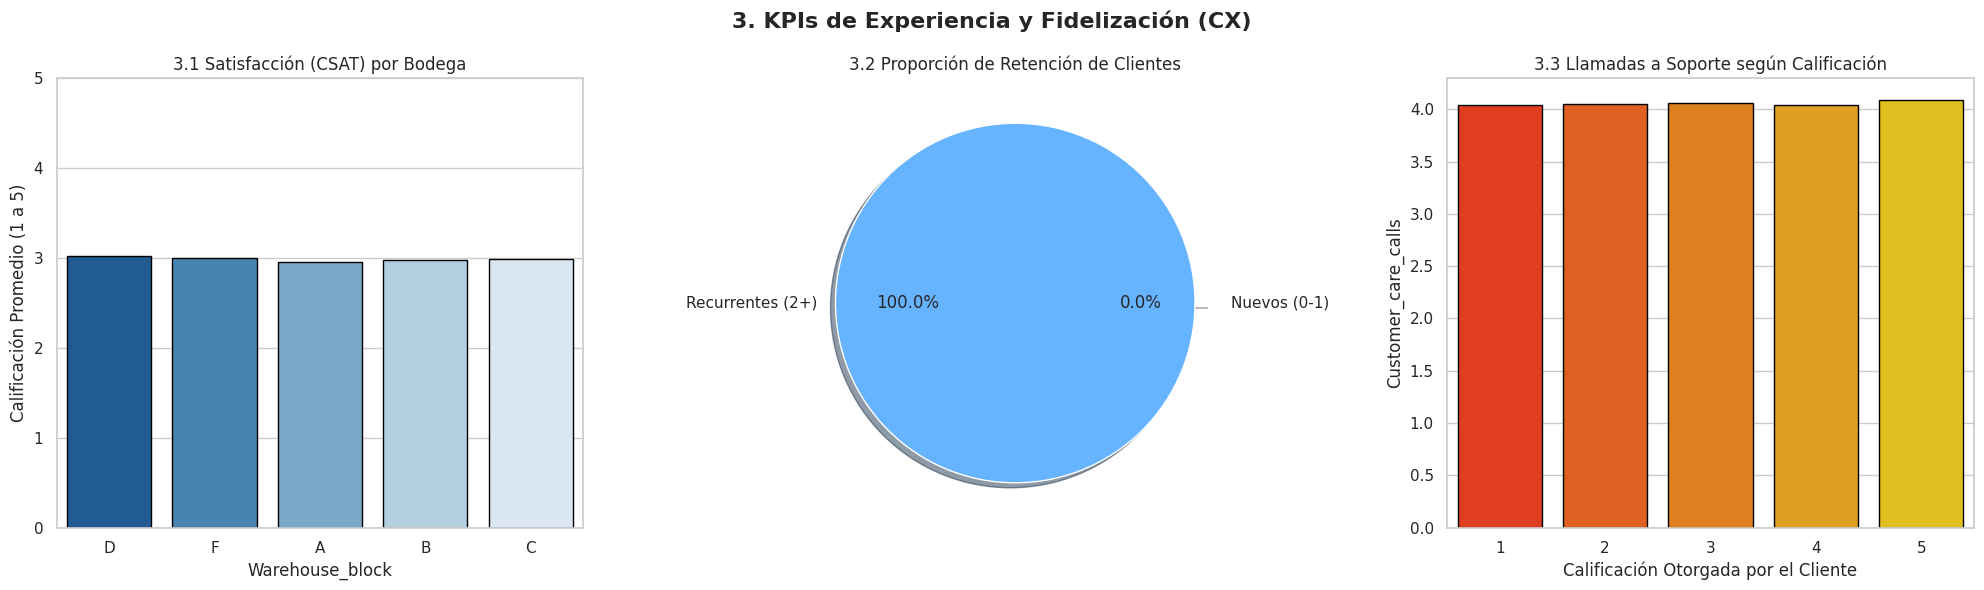

In [56]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('3. KPIs de Experiencia y Fidelización (CX)', fontsize=16, fontweight='bold')

# KPI 3.1: Índice de Satisfacción (CSAT) Promedio
sns.barplot(ax=axes[0], data=df_clean, x='Warehouse_block', y='Customer_rating', errorbar=None, palette='Blues_r', edgecolor='black')
axes[0].set_title('3.1 Satisfacción (CSAT) por Bodega')
axes[0].set_ylabel('Calificación Promedio (1 a 5)')
axes[0].set_ylim(0, 5)

# KPI 3.2: Tasa de Retención
retencion = ['Nuevos (0-1)', 'Recurrentes (2+)']
valores_retencion = [df_clean[df_clean['Prior_purchases'] < 2].shape[0], df_clean[df_clean['Prior_purchases'] >= 2].shape[0]]
axes[1].pie(valores_retencion, labels=retencion, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], explode=(0.1, 0), shadow=True)
axes[1].set_title('3.2 Proporción de Retención de Clientes')

# KPI 3.3: Carga de Soporte por Cliente
sns.barplot(ax=axes[2], data=df_clean, x='Customer_rating', y='Customer_care_calls', errorbar=None, palette='autumn', edgecolor='black')
axes[2].set_title('3.3 Llamadas a Soporte según Calificación')
axes[2].set_xlabel('Calificación Otorgada por el Cliente')

plt.tight_layout()
plt.show()

# Conclusiones de la Auditoría de Desempeño

A partir de los 13 KPIs analizados en el presente dashboard, se destacan los siguientes hallazgos estratégicos:

**1. Rentabilidad M-Commerce vs. E-Commerce**
* **Tráfico y Revenue:** Se identificó la plataforma con mayor tasa de conversión y generación de liquidez.
* **Ticket Promedio :** El análisis cruzado por categorías permite definir que canal es más efectivo para compras de alto valor frente a compras por impulso.

**2. Análisis Operativo y Comercial (E-Commerce)**
* **Logística y Almacenaje:** El costo de envío varía drásticamente según el transporte. Asimismo, la distribución en los bloques de bodega indica dónde priorizar la gestión de inventario para evitar cuellos de botella.
* **Estrategia Financiera:** El análisis de descuentos cruzado con las compras previas permite evaluar si las promociones están generando fidelidad real o si representan una pérdida de margen en clientes de única vez.
* **Experiencia del Cliente (CX):** Se evidencia que una baja calificación de satisfacción incrementa proporcionalmente la carga operativa de llamadas al equipo de soporte.

